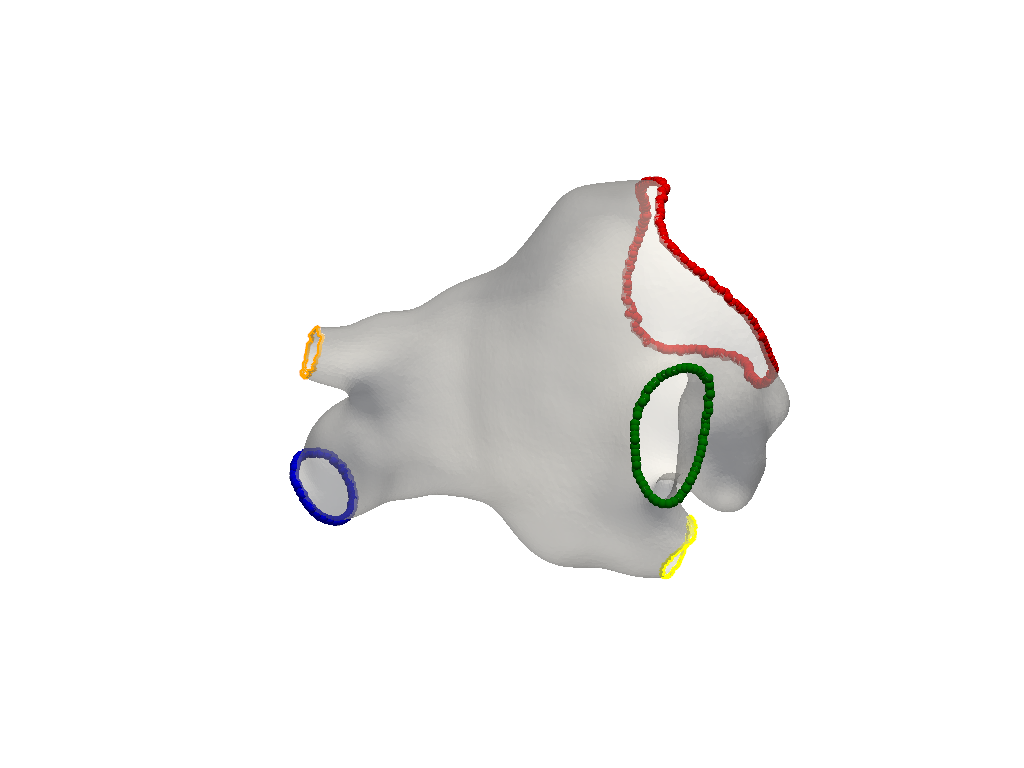

In [29]:
from pathlib import Path
import numpy as np
import pyvista as pv


path = Path("./data")

points = np.load(path / "atrial_points.npy")
elems = np.load(path / "atrial_elems.npy")

camera_position = [(-159.069, -285.733, 86.216),
                   (-33.103, -27.487, 75.834),
                   (-0.014, -0.033, -0.999)]

poly = pv.PolyData(points, np.hstack((np.full((elems.shape[0], 1), 3), elems)).astype(np.int64))
poly["point_ids"] = np.arange(points.shape[0])

#extract boundary edges
edges = poly.extract_feature_edges(boundary_edges=True, feature_edges=False, manifold_edges=False, non_manifold_edges=False)

# separate the edges into connected lines
lines = edges.connectivity()

groups = lines["RegionId"]
grouped_lines = [lines.extract_cells(groups == i) for i in np.unique(groups)]
grouped_lines = sorted(grouped_lines, key=lambda x: x.n_points, reverse=True)
grouped_colors = ["red", "green", "blue", "yellow", "orange", "purple", "cyan", "magenta"]

mv_point_ids = grouped_lines[0].point_data["point_ids"]
lspv_point_ids = grouped_lines[1].point_data["point_ids"]
ripv_point_ids = grouped_lines[2].point_data["point_ids"]

mv_points = points[mv_point_ids]
lspv_points = points[lspv_point_ids]
ripv_points = points[ripv_point_ids]

pv.set_jupyter_backend("static")
pl = pv.Plotter()
pl.camera_position = camera_position
pl.add_mesh(poly, color="white", opacity=0.5, show_edges=False)
for i, line in enumerate(grouped_lines):
    pl.add_mesh(line, color=grouped_colors[i], line_width=5)

pl.add_points(mv_points, color="red", point_size=10, render_points_as_spheres=True)
pl.add_points(lspv_points, color="green", point_size=10, render_points_as_spheres=True)
pl.add_points(ripv_points, color="blue", point_size=10, render_points_as_spheres=True)
pl.show()


In [ ]:
# pv.set_jupyter_backend("trame")

# # print camera position when rotating the plot

# pl = pv.Plotter(notebook=True)
# pl.add_mesh(poly, scalars=u, show_edges=False)

# # pl.iren.add_observer(
# #     "InteractionEvent",
# #     lambda *_: print(pl.camera_position),
# # )

# pl.camera_position = camera_position
# pl.show()

Calculating the Geodesic Path: 100%|██████████[00:00<00:00]
Calculating the Geodesic Path: 100%|██████████[00:00<00:00]


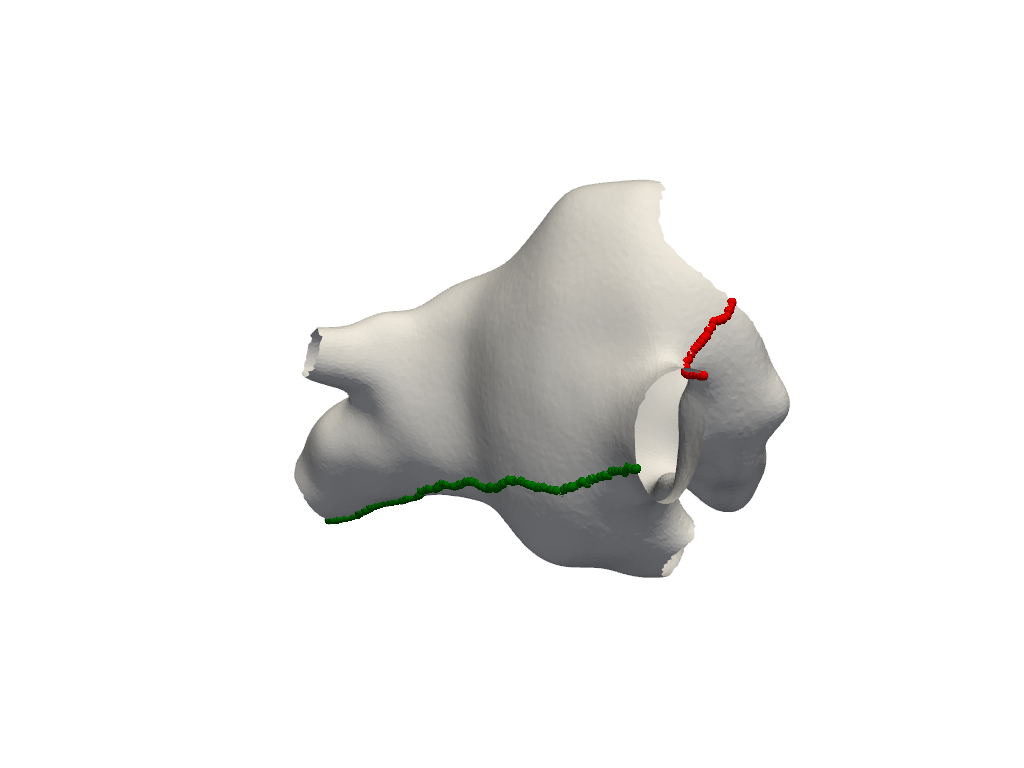

In [30]:
def closest_pair(points_a, points_b):
    from scipy.spatial import KDTree
    tree = KDTree(points_b)
    distances, indices_b = tree.query(points_a, k=1)

    index_a = np.argmin(distances)
    index_b = indices_b[index_a]

    return index_a, index_b

# find two closest points in s1 and s2
mv_lspv_closest, lspv_mv_closest = closest_pair(mv_points, lspv_points)
mv_lspv_closest = mv_point_ids[mv_lspv_closest]
lspv_mv_closest = lspv_point_ids[lspv_mv_closest]

lspv_ripv_closest, ripv_lspv_closest = closest_pair(lspv_points, ripv_points)
lspv_ripv_closest = lspv_point_ids[lspv_ripv_closest]
ripv_lspv_closest = ripv_point_ids[ripv_lspv_closest]

# find geodesic path between the two closest points using pyvista
mv_to_lspv = poly.geodesic(mv_lspv_closest, lspv_mv_closest, progress_bar=True)
mv_to_lspv_ids = mv_to_lspv.point_data["vtkOriginalPointIds"]

lspv_to_ripv = poly.geodesic(lspv_ripv_closest, ripv_lspv_closest, progress_bar=True)
lspv_to_ripv_ids = lspv_to_ripv.point_data["vtkOriginalPointIds"]

pv.set_jupyter_backend("static")
pl = pv.Plotter()
pl.camera_position = camera_position
pl.add_mesh(poly, color="white", opacity=1., show_edges=False)
pl.add_points(points[mv_to_lspv_ids], color="red", render_points_as_spheres=True, point_size=10)
pl.add_points(points[lspv_to_ripv_ids], color="green", render_points_as_spheres=True, point_size=10)
pl.show()

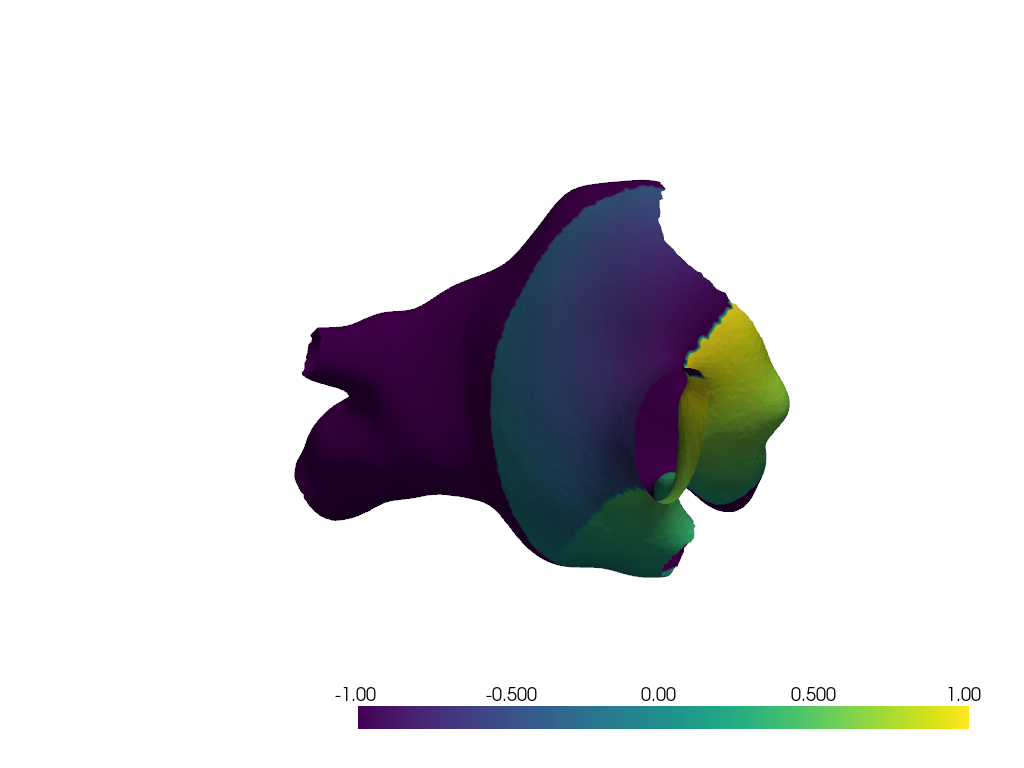

In [31]:
import numpy as np
import finitewave as fw
from finitewave_tools import linalg as fwlinalg


tissue = fw.CardiacTissueElements(points, elems, elem_type=fw.ElementType.TRIANGLE)
tissue.conductivity = 2.

spatial_discretization = fw.FiniteElementDiscretization()
K, M = spatial_discretization.compute_weights(tissue)

areas = spatial_discretization.compute_elements_size(points, elems)
G = spatial_discretization.compute_gradients(points, elems)

vec_mv = fwlinalg.distance_direction(K, M, G, elems, lspv_point_ids)
vec_circ = fwlinalg.distance_direction(K, M, G, elems, mv_to_lspv_ids)
elem_centers = np.mean(points[elems], axis=1)

vec_normal = poly.compute_normals(cell_normals=True, point_normals=False, inplace=False).cell_normals

# make sure the vectors form a right-handed coordinate system
# flip the vec_circ if it is not orthogonal to vec_mv and vec_normal
dot_product = np.einsum('ij,ij->i', vec_circ, np.cross(vec_mv, vec_normal))
vec_circ[dot_product < 0] *= -1

circ_dist = fwlinalg.geodesic_distance(K, M, G, elems, areas, mv_to_lspv_ids)
lspv_dist = fwlinalg.geodesic_distance(K, M, G, elems, areas, lspv_point_ids)

circ_dist[lspv_dist > 20] = 0.0
circ_dist = 1 - circ_dist / circ_dist.max()

# convert cell data to point data for visualization
poly["dot_product"] = dot_product
poly = poly.cell_data_to_point_data(pass_cell_data=True)
dot_product = poly.point_data["dot_product"]

circ_dist[dot_product < 0] *= -1
circ_dist[lspv_dist > 20] = -1.0

pv.set_jupyter_backend("static")
pl = pv.Plotter()
pl.add_mesh(poly, scalars=circ_dist, cmap="viridis", opacity=1)
pl.camera_position = camera_position
pl.show()

Running Courtemanche on (50, 1) Grid: 100%|██████████| 30000/30000 [00:04<00:00, 6135.55it/s] 


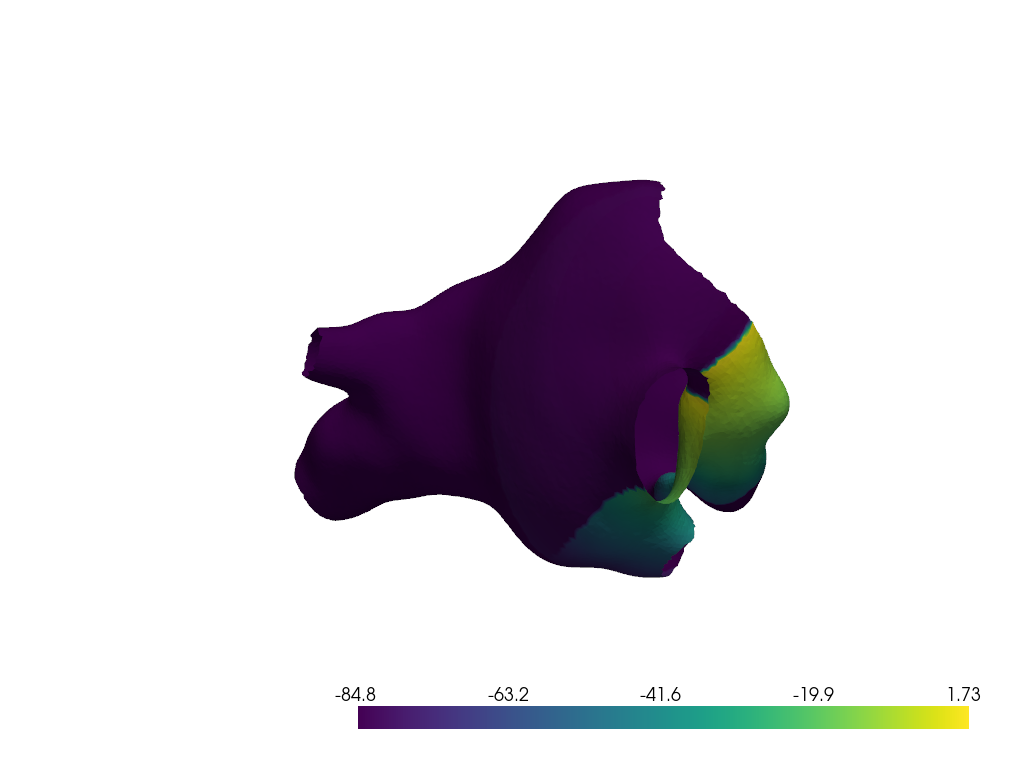

In [32]:

import numpy as np
import pyvista as pv

import finitewave as fw
import numpy as np


stim_prepacing = fw.StimSingleCell(dt=0.01)
stim_prepacing.add_stim(n_beats=100, cycle_length=1000, duration=1, curr_value=0.5)
stim_prepacing.add_stim(n_beats=100, cycle_length=500, duration=1, curr_value=0.5)
stim_prepacing.add_stim(n_beats=100, cycle_length=500, duration=1, curr_value=0.5)

remodeled_params =dict(
    gk1 = 2 * 0.09,
    gks = 2 * 0.129,
    gkr = 1.6 * 0.0294,
    gkur = 0.5 * 1.0,
    gcal = 0.45 * 0.1238,
    gto = 0.35 * 0.1652,
    ipcamax = 1.5 * 0.6,
    inacamax = 1.6 * 1600.0
)

cardiac_model = fw.Courtemanche()
cardiac_model.set_parameters(remodeled_params)
cardiac_model.prepacing(stim_prepacing)

# create a tissue of size 50x10 to collect the state variables.
n, m = 50, 1
tissue = fw.CardiacTissue([n, m], dr=0.25)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimCurrentCoord(time=0, curr_value=100, duration=2,
                                           x_min=0, x_max=1, y_min=0, y_max=m))

state_tracker = fw.MultiVariableTracker(node_inds=[(n//2, m//2)], step=10, start_time=0)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(state_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=300, backend="numba")

simulation.cardiac_model = cardiac_model
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

state_vars = {}
n_levels = len(state_tracker.tracking_times)
state_map = n_levels - np.digitize(circ_dist, bins=np.linspace(-1, 1, n_levels))
for var_name in cardiac_model.state_vars:
    tracked_values = state_tracker.output[var_name]
    var_array = tracked_values[state_map]
    state_vars[var_name] = var_array


pv.set_jupyter_backend("static")

pl = pv.Plotter()
pl.camera_position = camera_position
pl.add_mesh(poly, scalars=state_vars["u"], show_edges=False)
pl.show()


Running Courtemanche on Triangle Elements: 100%|██████████| 99999/99999 [02:51<00:00, 581.61it/s] 


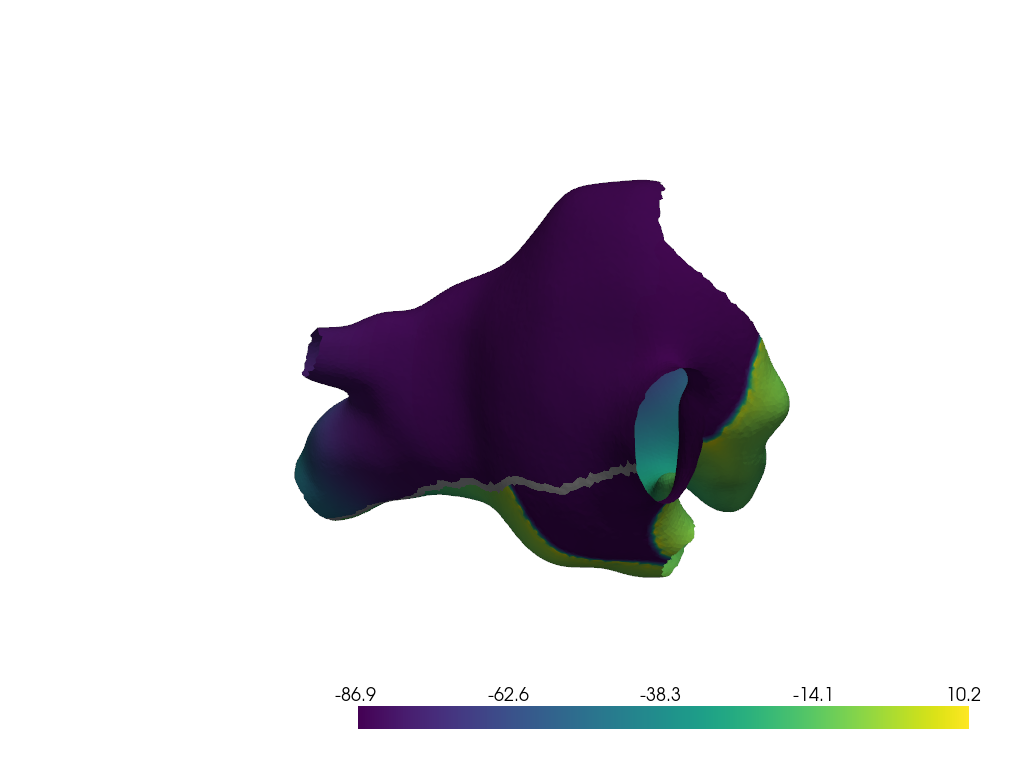

In [34]:


class Ablate(fw.Command):
    def __init__(self, time, ablation_ids):
        super().__init__(time=time)
        self.ablation_ids = ablation_ids

    def execute(self, simulation):
        simulation.cardiac_tissue.mesh[self.ablation_ids] = 2
        simulation.spatial_discretization.update_weights()
        simulation.time_integration.assemble_system()
        simulation.cardiac_model._u = simulation.backend.set_flat_values(
            simulation.cardiac_model._u, self.ablation_ids, np.nan
        )
        simulation.time_integration.u = simulation.backend.set_flat_values(
            simulation.time_integration.u, self.ablation_ids, np.nan
        )
        simulation.time_integration.u_old = simulation.backend.set_flat_values(
            simulation.time_integration.u_old, self.ablation_ids, np.nan
        )
        simulation.time_integration.u_old_2 = simulation.backend.set_flat_values(
            simulation.time_integration.u_old_2, self.ablation_ids, np.nan
        )


cardiac_model = fw.Courtemanche()
cardiac_model.set_parameters(remodeled_params)
cardiac_model.prepacing(stim_prepacing)
cardiac_model.set_variables(state_vars)

anim_tracker = fw.AnimationTracker(step=200, start_time=0, animation_name="lspv_to_ripv_ablation")

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.015, t_max=1500, backend="jax")
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = fw.CardiacTissue(coords=points, elems=elems,
                                             elem_type=fw.ElementType.TRIANGLE)
simulation.cardiac_model = cardiac_model
# set up time integration:
simulation.time_integration = fw.BackwardEulerTimeIntegration(atol=1e-6, maxiter=100)
simulation.tracker_sequence = fw.TrackerSequence()
simulation.tracker_sequence.add_tracker(anim_tracker)
simulation.command_sequence = fw.CommandSequence()
simulation.command_sequence.add_command(Ablate(time=500, ablation_ids=lspv_to_ripv_ids))

# run the model:
simulation.run()

# get the resulting potential at the element centers:
u = simulation.cardiac_model.u

pv.set_jupyter_backend("static")
pl = pv.Plotter()
pl.camera_position = camera_position
pl.add_mesh(poly, scalars=u, show_edges=False)
pl.show()

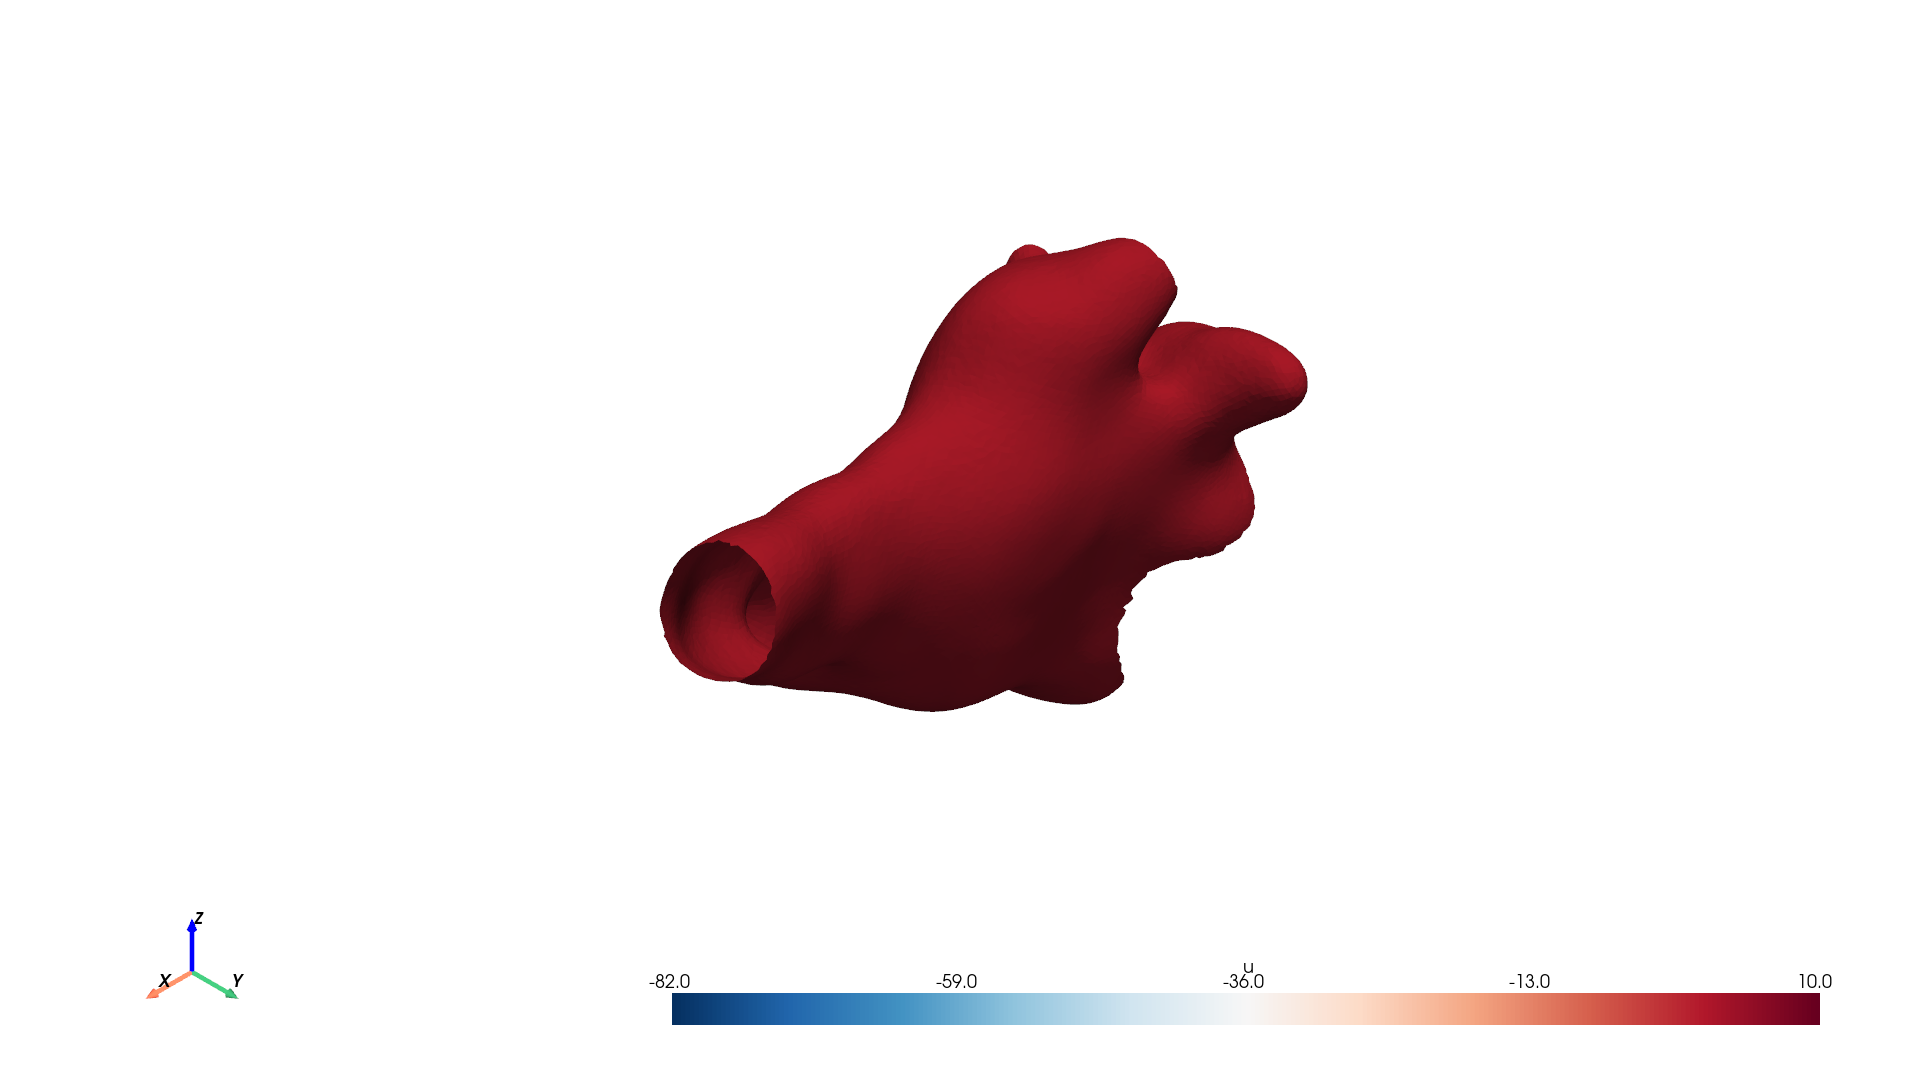

Building animation: 100%|██████████| 500/500 [00:28<00:00, 17.56it/s]


In [35]:
anim_tracker.write(clim=[-82, 10], fps=24, camera_position=camera_position, clear=False)

Running Courtemanche on Triangle Elements: 100%|██████████| 99999/99999 [02:24<00:00, 693.61it/s] 


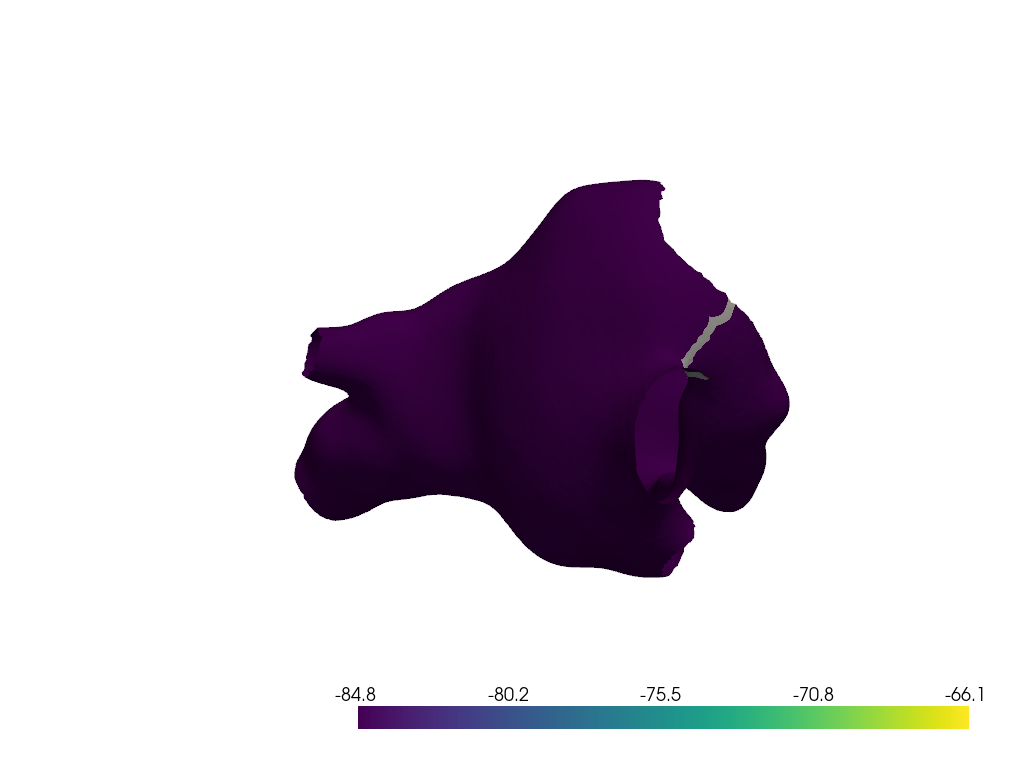

In [36]:
cardiac_model = fw.Courtemanche()
cardiac_model.set_parameters(remodeled_params)
cardiac_model.prepacing(stim_prepacing)
cardiac_model.set_variables(state_vars)

anim_tracker = fw.AnimationTracker(step=200, start_time=0, animation_name="mv_to_lspv_ablation")

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.015, t_max=1500, backend="jax")
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = fw.CardiacTissue(coords=points, elems=elems,
                                             elem_type=fw.ElementType.TRIANGLE)
simulation.cardiac_model = cardiac_model
# set up time integration:
simulation.time_integration = fw.BackwardEulerTimeIntegration(atol=1e-6, maxiter=100)
simulation.tracker_sequence = fw.TrackerSequence()
simulation.tracker_sequence.add_tracker(anim_tracker)
simulation.command_sequence = fw.CommandSequence()
simulation.command_sequence.add_command(Ablate(time=500, ablation_ids=mv_to_lspv_ids))

# run the model:
simulation.run()

# get the resulting potential at the element centers:
u = simulation.cardiac_model.u

pv.set_jupyter_backend("static")
pl = pv.Plotter()
pl.camera_position = camera_position
pl.add_mesh(poly, scalars=u, show_edges=False)
pl.show()

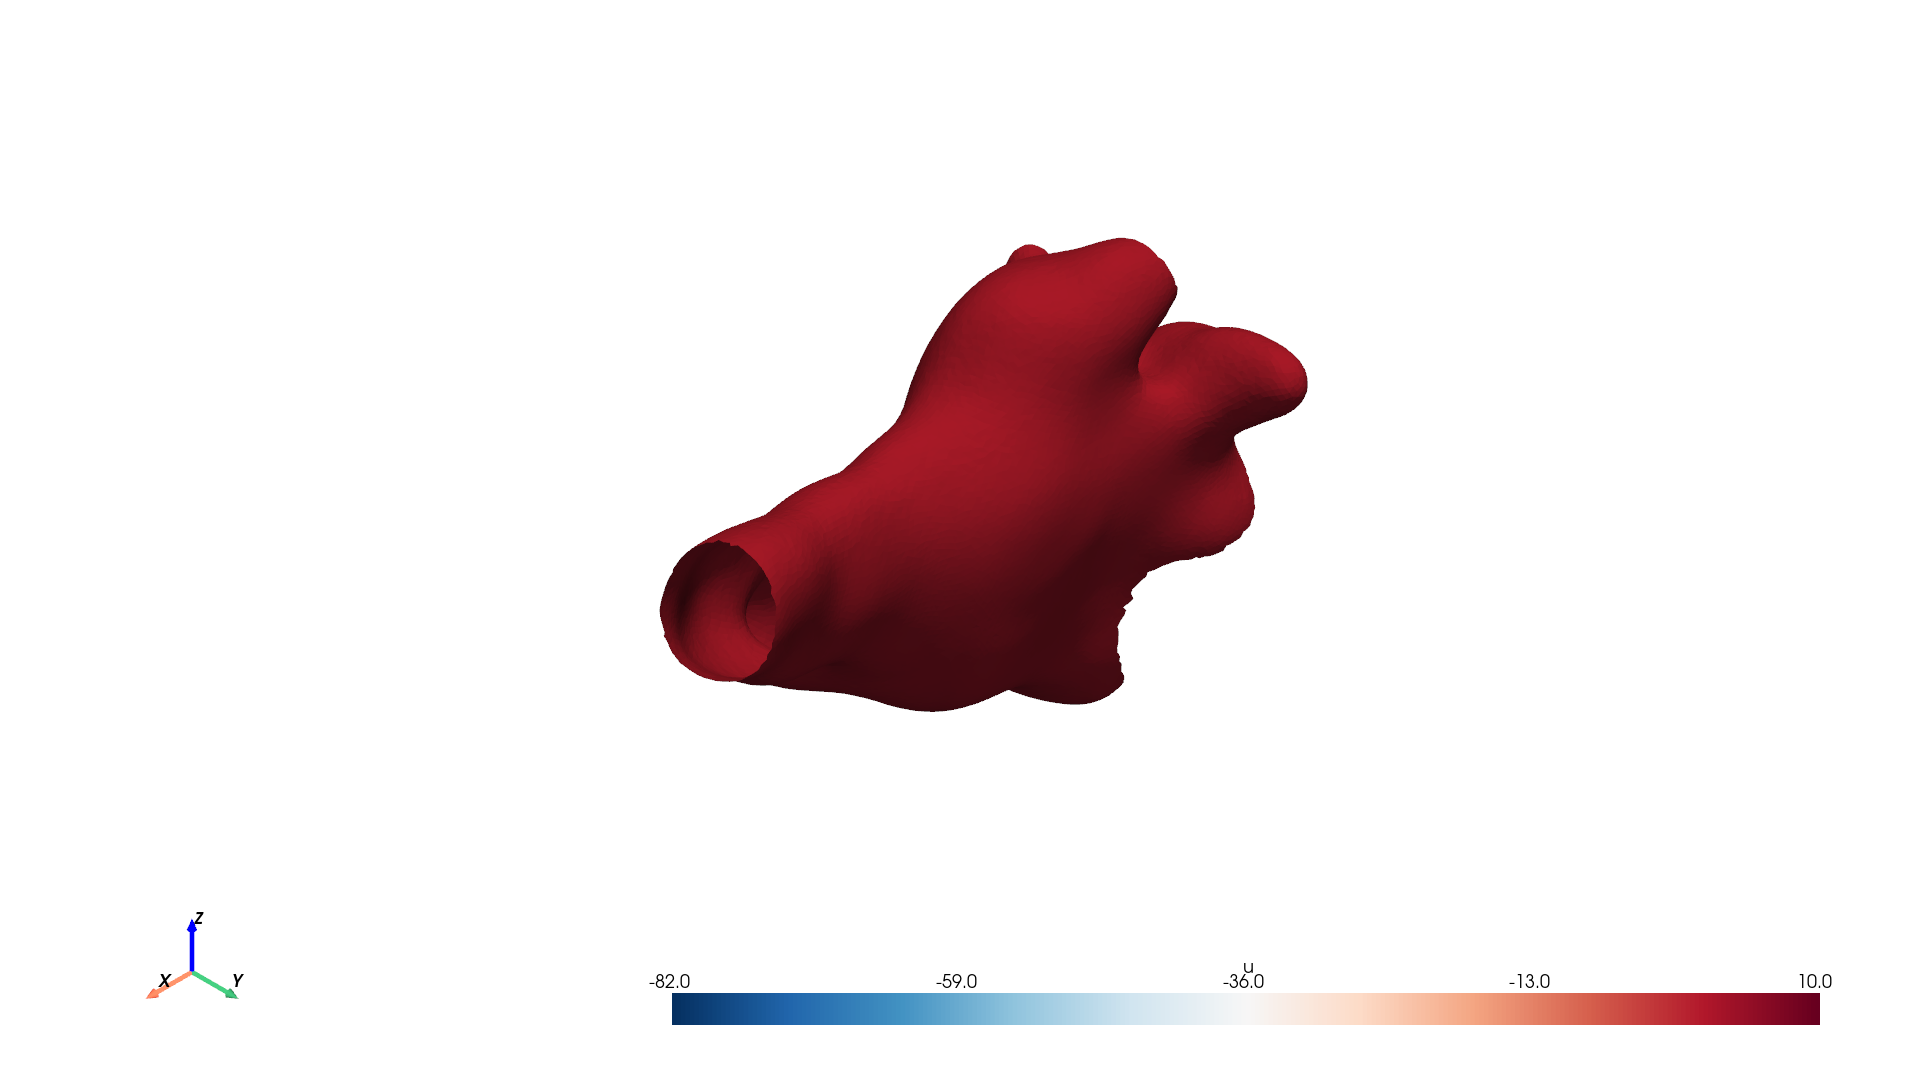

Building animation: 100%|██████████| 500/500 [00:28<00:00, 17.65it/s]


In [37]:
anim_tracker.write(clim=[-82, 10], fps=24, camera_position=camera_position, clear=False)